# 04 — Avaliação Comparativa (CNN-A vs. CNN-B)

Compara os dois modelos com métricas quantitativas, matrizes de confusão, sobreposição de curvas e análise qualitativa de erros. Requer que os notebooks 02 e 03 já tenham sido executados (pesos e históricos salvos).

In [1]:
# >>> NO GOOGLE COLAB: rode ESTA célula primeiro (em ambiente local, pule) <<<
# Clona o repositório. NÃO instalamos requirements.txt no Colab: ele já traz
# TensorFlow, Keras, numpy, pandas, scikit-learn, matplotlib, seaborn e
# tensorflow-datasets em versões compatíveis entre si. Reinstalar versões
# fixas rebaixa o ml_dtypes/numpy e quebra o JAX do Colab.
!git clone https://github.com/luanmacea/gs-cnn-eurosat.git
%cd gs-cnn-eurosat

Cloning into 'gs-cnn-eurosat'...
remote: Enumerating objects: 65, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 65 (delta 32), reused 46 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (65/65), 43.20 KiB | 6.17 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/gs-cnn-eurosat


In [2]:
import sys, os
# Resolve a raiz do projeto de forma robusta (local OU Colab, com ou sem
# restart de runtime). Procura uma pasta que contenha 'src/'.
candidatos = [os.getcwd(), os.path.dirname(os.getcwd()), '/content/gs-cnn-eurosat']
ROOT = next((p for p in candidatos if os.path.isdir(os.path.join(p, 'src'))), os.getcwd())
os.chdir(ROOT)  # paths relativos (models/, reports/) consistentes
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
print('Project root:', ROOT)

Project root: /content/gs-cnn-eurosat


In [3]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import load_model
from src.data_loader import load_raw_data, make_splits, make_tf_datasets, CLASS_NAMES
from src.train import load_history
from src.evaluate import (get_predictions, text_report, report_dataframe,
                          plot_confusion_matrix, compare_training_curves,
                          plot_misclassified)

## Dados de teste (mesma divisão — seed=42)

In [4]:
images, labels = load_raw_data()
splits = make_splits(images, labels, seed=42)
_, _, test_ds = make_tf_datasets(splits, batch_size=64)
x_test, y_test = splits['test']

Baixando EuroSAT RGB de: https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1
  falhou (HTTPError: HTTP Error 403: Forbidden)
Baixando EuroSAT RGB de: https://zenodo.org/record/7711810/files/EuroSAT_RGB.zip?download=1
  falhou (HTTPError: HTTP Error 403: Forbidden)
Baixando EuroSAT RGB de: https://madm.dfki.de/files/sentinel/EuroSAT.zip
  falhou (URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)>)
Fonte indisponivel -> _load_from_zip: URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)>
Baixando EuroSAT RGB via Hugging Face (blanchon/EuroSAT_RGB)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/3.38k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16200 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Dataset carregado: 16200 imagens.


## Carregar modelos e históricos

In [5]:
# === Treina os dois modelos NESTA sessão ===
# O Colab apaga o disco entre sessões; em vez de carregar arquivos dos
# notebooks 02/03 (que se perderam), treinamos aqui e usamos em memória.
from src.models import build_cnn_a, build_cnn_b
from src.train import compile_and_train, save_history

# precisamos de treino e validação além do test_ds já criado na célula acima
train_ds, val_ds, _ = make_tf_datasets(splits, batch_size=64)

# CNN-A (baseline)
model_a = build_cnn_a()
_hist_a = compile_and_train(
    model_a, train_ds, val_ds,
    epochs=30, lr=1e-3,
    checkpoint_path='models/cnn_a_best.keras',
    patience=5, use_reduce_lr=False,
)
save_history(_hist_a, 'reports/cnn_a_history.json')

# CNN-B (refinada)
model_b = build_cnn_b()
_hist_b = compile_and_train(
    model_b, train_ds, val_ds,
    epochs=60, lr=1e-3,
    checkpoint_path='models/cnn_b_best.keras',
    patience=12, use_reduce_lr=True,
)
save_history(_hist_b, 'reports/cnn_b_history.json')

hist_a = _hist_a.history
hist_b = _hist_b.history

Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.3807 - loss: 1.5530 - val_accuracy: 0.4366 - val_loss: 1.4725
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5451 - loss: 1.1536 - val_accuracy: 0.6115 - val_loss: 0.9849
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6762 - loss: 0.9032 - val_accuracy: 0.6844 - val_loss: 0.8796
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7229 - loss: 0.7685 - val_accuracy: 0.7395 - val_loss: 0.7068
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7413 - loss: 0.7233 - val_accuracy: 0.7309 - val_loss: 0.7316
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7560 - loss: 0.6670 - val_accuracy: 0.7502 - val_loss: 0.6799
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7711 - loss: 0.6252 - val_accuracy: 0.7757 - val_loss: 0.6232
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7848 - loss: 0.5860 - val_acc

## Predições no conjunto de teste

In [6]:
yt_a, yp_a, pr_a = get_predictions(model_a, test_ds)
yt_b, yp_b, pr_b = get_predictions(model_b, test_ds)

## Relatório de classificação (precision / recall / f1 por classe)

In [7]:
print('=== CNN-A (Baseline) ===  acurácia:', round(accuracy_score(yt_a, yp_a), 4))
print(text_report(yt_a, yp_a, CLASS_NAMES))
print('=== CNN-B (Refinada) ===  acurácia:', round(accuracy_score(yt_b, yp_b), 4))
print(text_report(yt_b, yp_b, CLASS_NAMES))

=== CNN-A (Baseline) ===  acurácia: 0.8247
                      precision    recall  f1-score   support

          AnnualCrop     0.8553    0.7472    0.7976       269
              Forest     0.8997    0.9701    0.9336       268
HerbaceousVegetation     0.7686    0.7259    0.7467       270
             Highway     0.6584    0.7080    0.6823       226
          Industrial     0.8735    0.9554    0.9126       224
             Pasture     0.7216    0.7095    0.7155       179
       PermanentCrop     0.6721    0.7387    0.7039       222
         Residential     0.9253    0.9319    0.9286       279
               River     0.8040    0.7306    0.7656       219
             SeaLake     0.9962    0.9562    0.9758       274

            accuracy                         0.8247      2430
           macro avg     0.8175    0.8174    0.8162      2430
        weighted avg     0.8266    0.8247    0.8244      2430

=== CNN-B (Refinada) ===  acurácia: 0.9021
                      precision    recall  

## Matrizes de confusão (normalizadas)

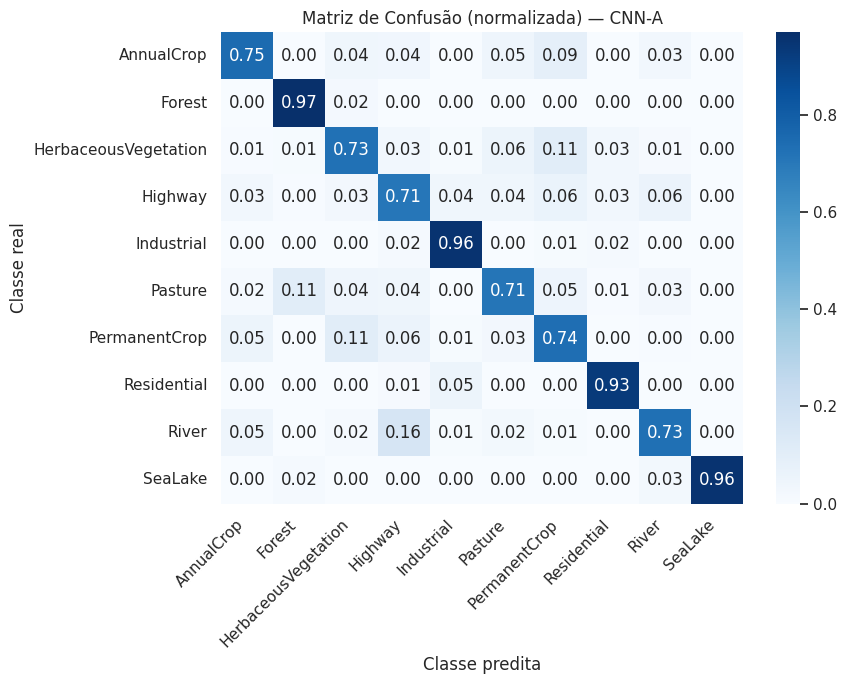

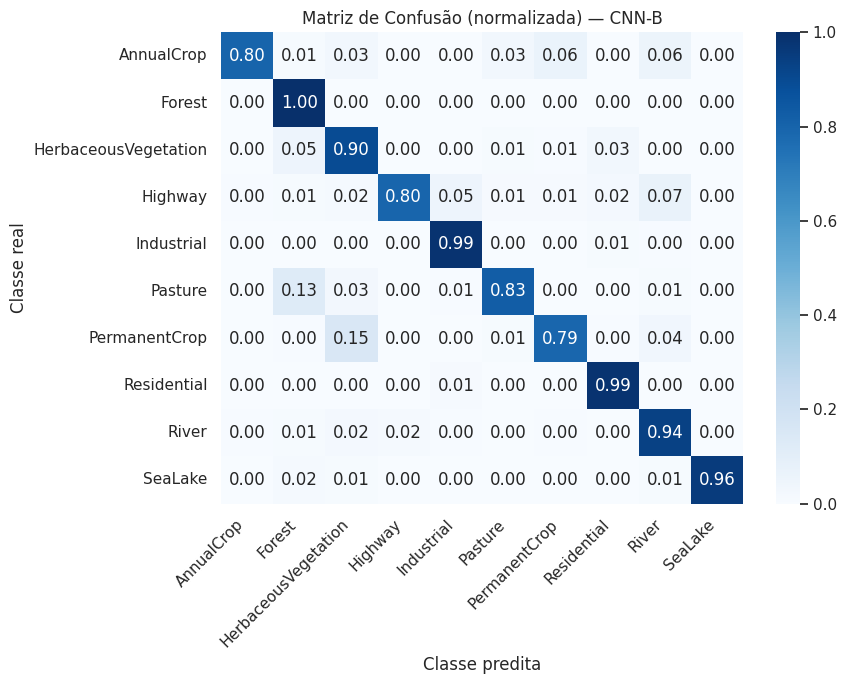

In [8]:
plot_confusion_matrix(yt_a, yp_a, CLASS_NAMES, title='CNN-A',
                      save_path='reports/figures/cm_cnn_a.png')
plot_confusion_matrix(yt_b, yp_b, CLASS_NAMES, title='CNN-B',
                      save_path='reports/figures/cm_cnn_b.png')

## Curvas de validação sobrepostas

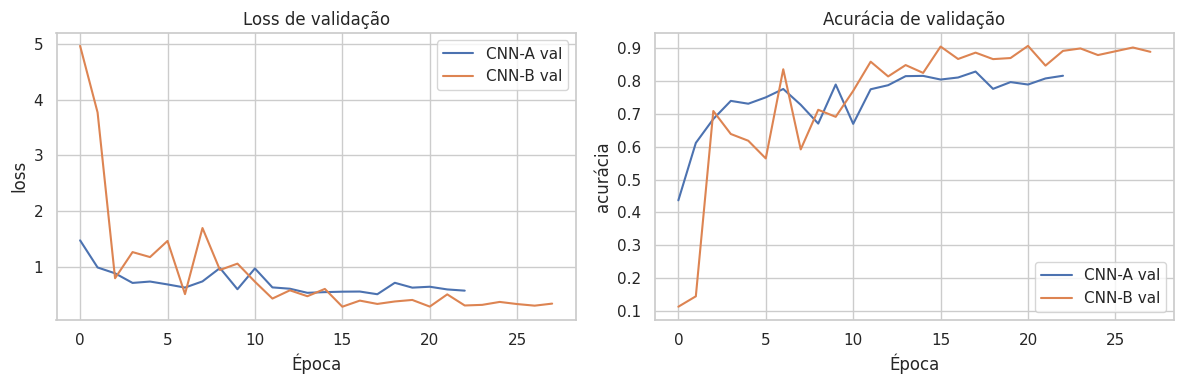

In [9]:
compare_training_curves(hist_a, hist_b,
                        save_path='reports/figures/comparacao_curvas.png')

## Análise qualitativa — erros da CNN-B
Imagens do conjunto de teste classificadas incorretamente, com classe real, classe predita e confiança.

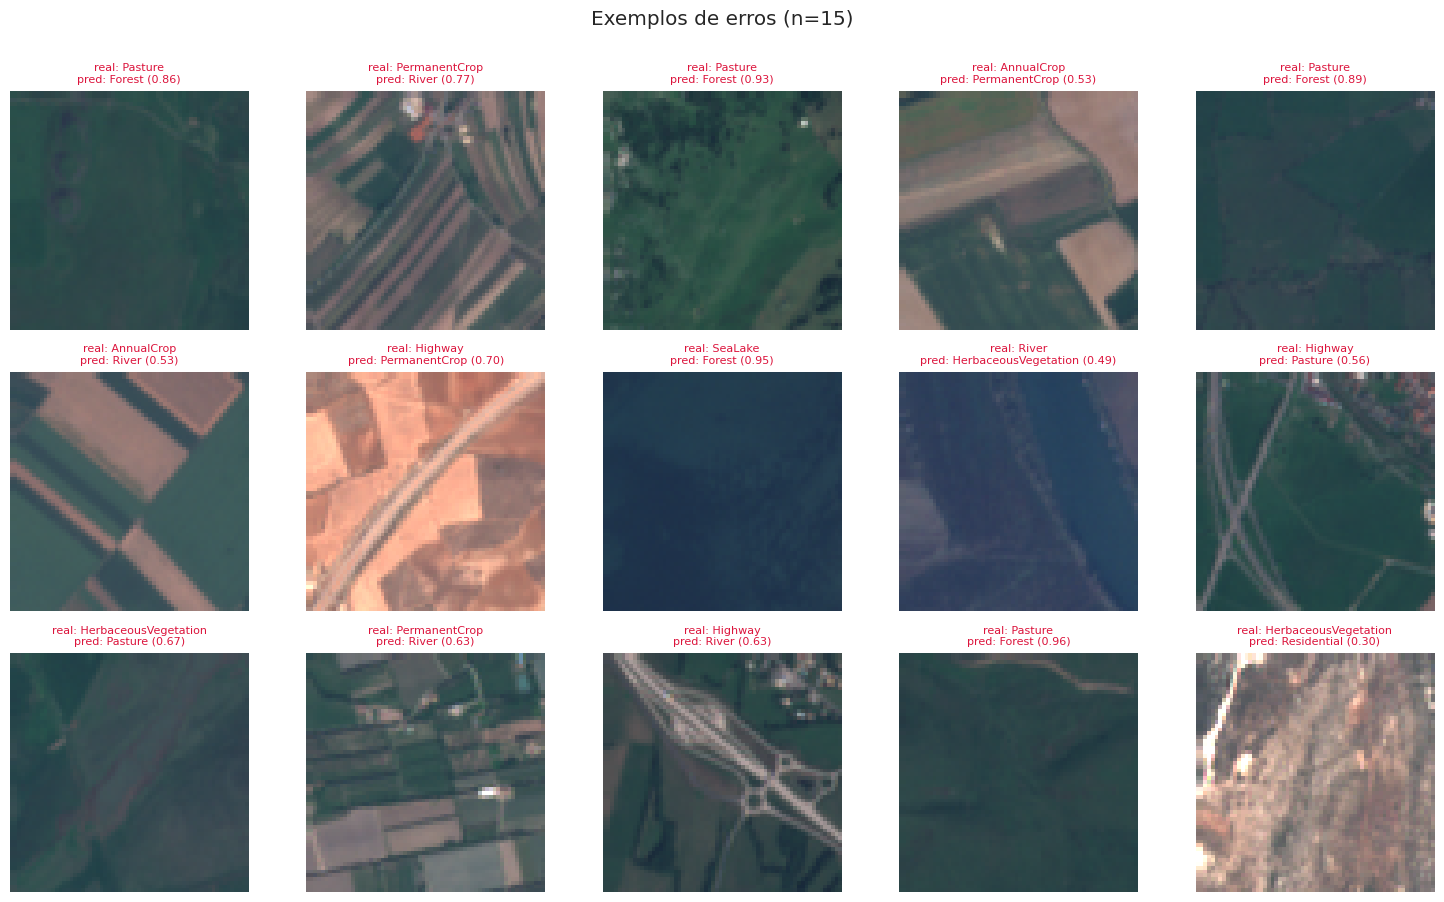

In [10]:
plot_misclassified(x_test, yt_b, yp_b, pr_b, CLASS_NAMES, n=15,
                   save_path='reports/figures/erros_cnn_b.png')

## Tabela comparativa final

In [11]:
tabela = pd.DataFrame({
    'Modelo': ['CNN-A (Baseline)', 'CNN-B (Refinada)'],
    'Parâmetros': [model_a.count_params(), model_b.count_params()],
    'Acc. validação (melhor)': [round(max(hist_a['val_accuracy']), 4),
                                 round(max(hist_b['val_accuracy']), 4)],
    'Acc. teste': [round(accuracy_score(yt_a, yp_a), 4),
                   round(accuracy_score(yt_b, yp_b), 4)],
})
tabela

,Modelo,Parâmetros,Acc. validação (melhor),Acc. teste
0,CNN-A (Baseline),684490,0.8288,0.8247
1,CNN-B (Refinada),1218378,0.9070,0.9021


## Análise técnica

*Preencha com base nos resultados reais acima. Estrutura sugerida:*

- **Qual modelo venceu e por quê:** a CNN-B deve superar a CNN-A em acurácia de teste e, principalmente, no gap treino–validação (generalização).
- **Efeito de cada técnica:** relacione a melhora à augmentation (robustez a variações), BatchNorm (treino estável), Dropout (regularização) e GAP (menos parâmetros, menos overfitting).
- **Confusões mais comuns (matriz):** classes de vegetação tendem a se confundir entre si — *AnnualCrop ↔ PermanentCrop ↔ HerbaceousVegetation ↔ Pasture* — por similaridade de textura/cor. Comente o que a matriz real mostrou.
- **Padrão dos erros:** descreva o que se observa nas imagens mal classificadas (ex.: confusões plausíveis vs. erros grosseiros).
- **Eficiência:** destaque que a CNN-B atinge desempenho superior com **menos** parâmetros que o baseline.